# NB05 - Regularizacion L1 (Lasso)

**Objetivos de aprendizaje**

- Definir el penalti L1 y contrastarlo con L2.
- Entender por que L1 puede producir coeficientes exactamente cero.
- Usar Lasso logistico para seleccion automatica de variables.
- Visualizar rutas de coeficientes y tablas de sparsity.
- Comparar fronteras de decision en dos dimensiones.

En todo el notebook mantenemos la convenci?n global del repositorio: `virginica = 1` es la clase positiva y `versicolor = 0` es la clase negativa.

**Referencias de este notebook**

- Tibshirani (1996): introduce Lasso como encogimiento y seleccion simultaneos.
- Hastie, Tibshirani & Friedman (2009): explican la geometria L1 y sus diferencias frente a L2.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## 1. Penalti L1 y geometria de sparsity

Lasso agrega `lambda * ||beta||_1`. La region L1 tiene esquinas; cuando la solucion toca una esquina, algunos coeficientes quedan exactamente en cero. Esa es la diferencia geometrica que Tibshirani (1996) exploto para seleccionar variables.


In [2]:
data = load_processed_splits(DATA_DIR)
X_train = data["X_train"]
X_train_scaled = data["X_train_scaled"]
y_train = data["y_train"]
feature_names = data["feature_names"]


## 2. Implementacion con scikit-learn


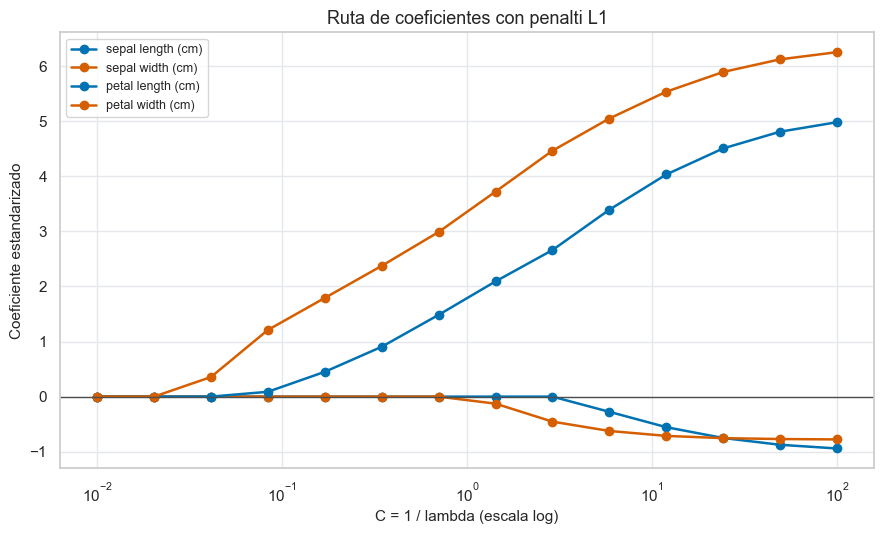

In [3]:
C_values = np.logspace(-2, 2, 14)
coefs_l1 = []
sparsity_rows = []

for C in C_values:
    # liblinear soporta L1 en problemas binarios y es estable para
    # este dataset pequeno. C pequeno implica mas ceros.
    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)
    coef = model.coef_.ravel()
    coefs_l1.append(coef)

    surviving = [name for name, value in zip(feature_names, coef) if abs(value) > 1e-8]
    sparsity_rows.append(
        {
            "C": C,
            "n_features_no_cero": len(surviving),
            "features_sobrevivientes": ", ".join(surviving) if surviving else "(ninguna)",
        }
    )

coefs_l1 = np.vstack(coefs_l1)
plot_regularization_path(C_values, coefs_l1, feature_names, "Ruta de coeficientes con penalti L1")
plt.show()


**Interpretacion.** A diferencia de Ridge, Lasso apaga variables por completo cuando la penalizacion es fuerte. Esta sparsity puede mejorar interpretabilidad, aunque tambien puede ser inestable si hay variables muy correlacionadas.


## 3. Tabla de variables sobrevivientes


In [4]:
sparsity_table = pd.DataFrame(sparsity_rows)
display(sparsity_table.round({"C": 4}))


,C,n_features_no_cero,features_sobrevivientes
0,0.0100,0,(ninguna)
1,0.0203,0,(ninguna)
2,0.0412,1,petal width (cm)
3,0.0838,2,"petal length (cm), petal width (cm)"
4,0.1701,2,"petal length (cm), petal width (cm)"
5,0.3455,2,"petal length (cm), petal width (cm)"
6,0.7017,2,"petal length (cm), petal width (cm)"
7,1.4251,3,"sepal width (cm), petal length (cm), petal wid..."
8,2.8943,3,"sepal width (cm), petal length (cm), petal wid..."
9,5.8780,4,"sepal length (cm), sepal width (cm), petal len..."


**Interpretacion.** La tabla muestra seleccion automatica: con `C` pequeno solo sobreviven las variables mas utiles o ninguna; al aumentar `C`, mas coeficientes pueden alejarse de cero.


## 4. Coeficientes de un modelo L1 representativo

Elegimos un `C` intermedio para observar que variables permanecen y con que signo.


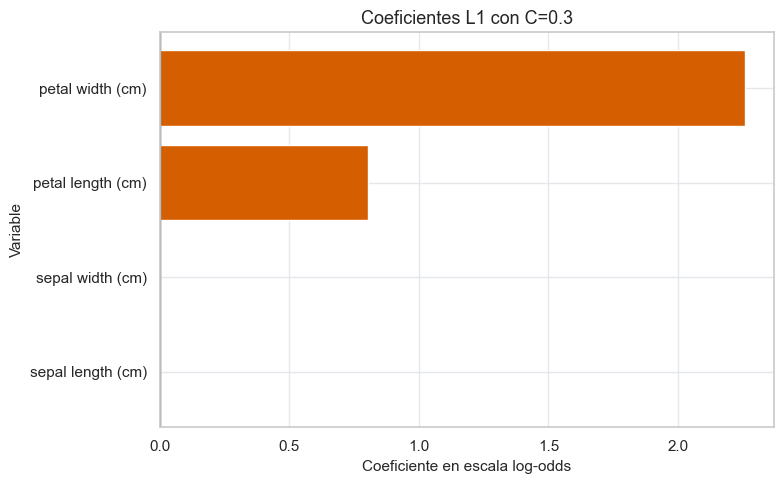

In [5]:
representative_l1 = LogisticRegression(
    penalty="l1",
    C=0.3,
    solver="liblinear",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
representative_l1.fit(X_train_scaled, y_train)
plot_coefficients(representative_l1.coef_.ravel(), feature_names, "Coeficientes L1 con C=0.3")
plt.show()


**Interpretacion.** Los coeficientes cero indican variables descartadas por el penalti. Hastie, Tibshirani & Friedman (2009) contrastan esta propiedad con L2: Ridge encoge, Lasso encoge y selecciona.


## 5. Frontera de decision L1 en 2D


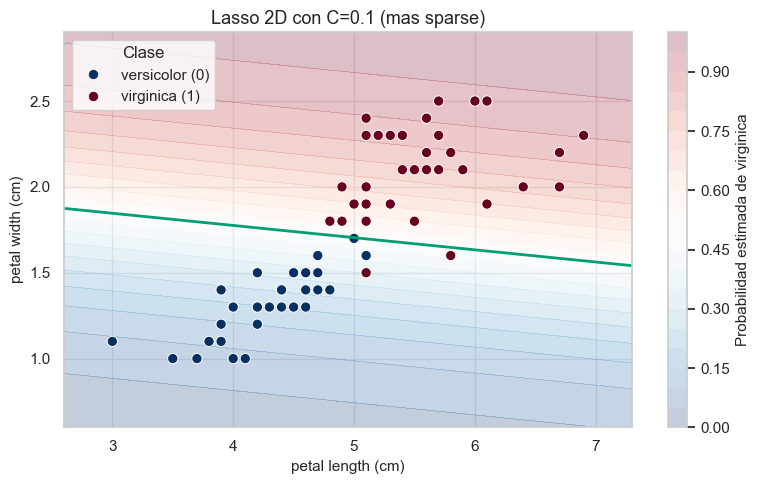

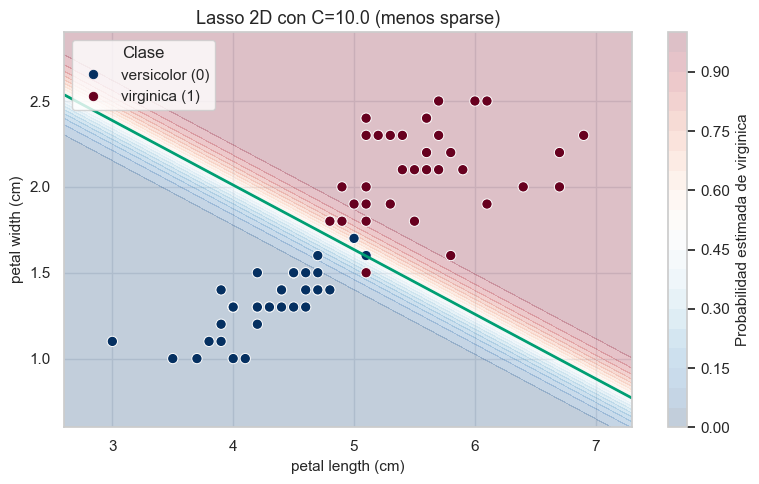

In [6]:
features_2d = ["petal length (cm)", "petal width (cm)"]
for C, label in [(0.1, "mas sparse"), (10.0, "menos sparse")]:
    model_2d = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=5000, random_state=RANDOM_STATE),
    )
    model_2d.fit(X_train[features_2d], y_train)
    plot_decision_boundary(
        model_2d,
        X_train[features_2d],
        y_train,
        features_2d,
        f"Lasso 2D con C={C} ({label})",
    )
    plt.show()


**Interpretacion.** Con regularizacion fuerte, L1 puede simplificar tanto que la frontera depende de menos variables. Con regularizacion debil, la frontera se parece mas a la logistica no penalizada.


## Resumen y conexion con la literatura

Tibshirani (1996) introdujo el Lasso como una forma de hacer encogimiento y seleccion de variables en una sola estimacion. Hastie, Tibshirani & Friedman (2009) explican que la geometria de la penalizacion L1 es la responsable de los coeficientes exactamente cero, propiedad que observamos en la ruta y en la tabla de variables sobrevivientes.
